In [2]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [3]:
# ============================================================================
# CELDA COLAB — Configuración para Google Colab (saltar en local)
# ============================================================================
# 1. Monta Google Drive:
#    from google.colab import drive; drive.mount('/content/drive')
# 2. Navega al repo:
#    import os; os.chdir('/content/drive/MyDrive/_MCD/TFM/MUDS-TFM/tfm-solar-forecasting/')
# 3. Instala dependencias:
#    (sin instalaciones adicionales — torch ya incluido en Colab)
#
# PRERREQUISITO: ejecutar 00_eda_preprocessing.ipynb para crear data/processed/
# ============================================================================

# Detección automática del entorno
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print('Ejecutando en Google Colab')
else:
    print('Ejecutando en entorno local')

Ejecutando en Google Colab


In [4]:
# ============================================================================
# EXPERIMENTO 2: LIGHTGBM PARA FORECASTING SOLAR
# Dataset: 14 plantas fotovoltaicas, 2025
# Objetivo: superar a Prophet (baseline) aprovechando lag features,
#           rolling stats e interacciones no lineales entre variables.
# ============================================================================

import sys
# Añadir src/ al path buscando la raíz del repo desde el directorio actual.
# En Google Colab: montar Drive y hacer os.chdir() al repo ANTES de ejecutar.
#   from google.colab import drive; drive.mount('/content/drive')
#   import os; os.chdir('/content/drive/MyDrive/.../tfm-solar-forecasting/')
import pathlib as _pl
_root = next(
    (p for p in [_pl.Path.cwd(), *_pl.Path.cwd().parents]
     if (p / 'src').is_dir() and (p / 'data' / 'processed').is_dir()),
    None
)
if _root is None:
    raise RuntimeError(
        f"No se encontró src/. cwd={_pl.Path.cwd()}\n"
        "En Colab: monta Drive y ejecuta os.chdir() al repo antes de %run."
    )
sys.path.insert(0, str(_root / 'src'))
del _pl, _root
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Módulos del proyecto
from lgbm_data_loader import LGBMFeatureBuilder, prepare_lgbm_data
from lgbm_model import LGBMForecaster, LGBMKFoldForecaster, _get_metric_key
from evaluation import ForecastEvaluator

# Módulo de armonización ex1_compare
from ex1_compare import PLANTAS, SMOKE_TEST, SMOKE_MAX_ROWS, DATA_DIR, RESULTS_DIR, CHECKPOINTS_DIR
from ex1_compare import plot_diagnostic, plot_timeseries, plot_model_comparison, plot_learning_curves
from ex1_compare import ResultsManager

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Inicializar gestor de resultados
rm = ResultsManager('lightgbm', results_dir=RESULTS_DIR, checkpoints_dir=CHECKPOINTS_DIR)

print('=' * 80)
print('EXPERIMENTO 2: LIGHTGBM')
print(f'Plantas: {PLANTAS}')
print(f'Smoke test: {SMOKE_TEST}')
print('=' * 80)

[ex1] Entorno: Google Colab | Device: cpu (CUDA no disponible)
ResultsManager [lightgbm]
  Figuras:     /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm
  Metricas:    /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics
  Checkpoints: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/lightgbm
EXPERIMENTO 2: LIGHTGBM
Plantas: ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA', 'TALASOL']
Smoke test: False


In [5]:
# ============================================================================
# 1. CARGAR DATOS
# ============================================================================

print('[1/6] Cargando datos...')

df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_val   = pd.read_csv(DATA_DIR / 'val.csv')
df_test  = pd.read_csv(DATA_DIR / 'test.csv')

# Cargar métricas de Prophet para comparación (desde ex1_compare si disponible, sino legacy)
prophet_path = rm.metrics_dir / 'prophet_metrics_summary.csv'
if not prophet_path.exists():
    prophet_path = Path('../results/metrics/prophet_metrics_summary.csv')
df_prophet = pd.read_csv(prophet_path) if prophet_path.exists() else pd.DataFrame()

plantas = sorted(df_train['planta_nombre'].unique())

print(f'  Train: {len(df_train):,} registros')
print(f'  Val:   {len(df_val):,} registros')
print(f'  Test:  {len(df_test):,} registros')
print(f'  Plantas: {len(plantas)}')

plantas_run = PLANTAS
print(f'\n  Ejecutando sobre: {plantas_run}')

[1/6] Cargando datos...
  Train: 50,917 registros
  Val:   6,780 registros
  Test:  8,922 registros
  Plantas: 6

  Ejecutando sobre: ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA', 'TALASOL']


In [6]:
# ============================================================================
# 2. CONFIGURACIÓN
# ============================================================================

print('[2/6] Configuración...')

# Features del builder
LAG_STEPS       = [1, 2, 3, 24, 48, 168]   # h: tendencia inmediata, día, semana
ROLLING_WINDOWS = [3, 6, 24]               # ventanas rolling mean/std

# Hiperparámetros LightGBM
LGBM_PARAMS = {
    'objective':         'regression_l1',  # optimizar MAE directamente
    'metric':            'mae',
    'num_leaves':         31,
    'min_data_in_leaf':   20,
    'lambda_l1':          0.1,
    'lambda_l2':          0.1,
    'feature_fraction':   0.8,
    'bagging_fraction':   0.8,
    'bagging_freq':       5,
    'learning_rate':      0.05,
    'n_estimators':       1000,
    'seed':               42,
    'verbose':            -1,
    'n_jobs':             -1,
}

USE_KFOLD      = True    # True = ensemble K-Fold, False = split fijo (más rápido)
N_SPLITS       = 5       # número de folds (LGBM es muy rápido, 5 es viable)
EARLY_STOPPING = 50      # rondas sin mejora en val antes de parar

print(f'  Lags:    {LAG_STEPS}')
print(f'  Rolling: {ROLLING_WINDOWS}')
print(f'  Modo:    {"K-Fold ("+str(N_SPLITS)+" folds)" if USE_KFOLD else "Split fijo"}')
print(f'  Objetivo loss: {LGBM_PARAMS["objective"]}')

[2/6] Configuración...
  Lags:    [1, 2, 3, 24, 48, 168]
  Rolling: [3, 6, 24]
  Modo:    K-Fold (5 folds)
  Objetivo loss: regression_l1


In [7]:
# ============================================================================
# 3. ENTRENAMIENTO POR PLANTA
# ============================================================================

import time

print('[3/6] Entrenamiento LightGBM por planta')
print('=' * 80)

_HAS_VALID = 'valid_data' in df_train.columns

all_models   = {}
all_builders = {}
results_all  = []
training_times = {}  # planta → segundos de entrenamiento

for i, planta in enumerate(plantas_run, 1):
    print(f'\n{"=" * 80}')
    print(f'PLANTA {i}/{len(plantas_run)}: {planta}')
    info = df_train[df_train['planta_nombre'] == planta].iloc[0]
    print(f'Zona: {info["zona_climatica"]}  |  Capacidad: {info["instalada_mw"]:.1f} MW')
    print('=' * 80)

    # ── Preparar features ────────────────────────────────────────────────────
    builder = LGBMFeatureBuilder(
        lag_steps=LAG_STEPS,
        rolling_windows=ROLLING_WINDOWS
    )
    df_tr, df_va, df_te, feat, builder = prepare_lgbm_data(
        df_train, df_val, df_test,
        planta=planta,
        builder=builder,
        solo_diurno=True
    )
    all_builders[planta] = builder

    # Excluir horas inválidas del entrenamiento (curtailment + huecos largos)
    if _HAS_VALID:
        n_before_tr = len(df_tr)
        n_before_va = len(df_va)
        df_tr = df_tr[df_tr['valid_data'].fillna(True).astype(bool)]
        df_va = df_va[df_va['valid_data'].fillna(True).astype(bool)]
        n_excl_tr = n_before_tr - len(df_tr)
        n_excl_va = n_before_va - len(df_va)
        if n_excl_tr + n_excl_va > 0:
            print(f'  ⚠ Excluidas del entrenamiento: {n_excl_tr} train + {n_excl_va} val (valid_data=False)')

    # ── Entrenar ─────────────────────────────────────────────────────────────
    t0 = time.time()

    if USE_KFOLD:
        # Combinar train+val para K-Fold
        df_tv = pd.concat([df_tr, df_va]).sort_values('timestamp_utc').reset_index(drop=True)

        model = LGBMKFoldForecaster(
            n_splits=N_SPLITS,
            lgbm_params=LGBM_PARAMS,
            early_stopping=EARLY_STOPPING
        )
        model.fit(df_tv, feat, planta_nombre=planta, verbose_eval=0)

        # Predicciones en test (solo horas diurnas)
        y_pred = model.predict(df_te[feat])

    else:
        model = LGBMForecaster(params=LGBM_PARAMS, early_stopping=EARLY_STOPPING)
        model.fit(
            df_tr, df_tr['produccion'],
            df_va, df_va['produccion'],
            feature_names=feat,
            planta_nombre=planta,
            verbose_eval=100
        )
        y_pred = model.predict(df_te[feat])

    training_times[planta] = time.time() - t0
    print(f'  Tiempo entrenamiento: {training_times[planta]:.1f} s')

    all_models[planta] = model

    # Guardar checkpoint
    rm.save_checkpoint(model, planta)

    # ── Resultados (todas las horas: nocturnas con y_pred=0.0) ───────────────
    df_pred_dia = pd.DataFrame({
        'timestamp': df_te['timestamp_utc'].astype(str).str[:19],
        'y_pred':    y_pred,
    })
    # Completar con horas nocturnas (y_pred = 0.0)
    df_test_planta = df_test[df_test['planta_nombre'] == planta][
        ['timestamp_utc', 'produccion', 'planta_nombre']
    ].copy()
    df_test_planta = df_test_planta.rename(
        columns={'timestamp_utc': 'timestamp', 'produccion': 'y_true'}
    )
    df_test_planta['timestamp'] = df_test_planta['timestamp'].astype(str).str[:19]
    df_pred = df_test_planta.merge(df_pred_dia[['timestamp', 'y_pred']], on='timestamp', how='left')
    df_pred['y_pred'] = df_pred['y_pred'].fillna(0.0)

    # Añadir metadatos (incluyendo valid_data si existe)
    meta_cols = ['timestamp_utc', 'planta_nombre', 'hora', 'mes',
                 'cloud_cover', 'zona_climatica']
    if _HAS_VALID:
        meta_cols.append('valid_data')
    df_pred = df_pred.merge(
        df_test[[c for c in meta_cols if c in df_test.columns]],
        left_on=['timestamp', 'planta_nombre'],
        right_on=['timestamp_utc', 'planta_nombre'],
        how='left'
    )
    results_all.append(df_pred)

    # Métricas rápidas (solo horas válidas)
    if _HAS_VALID and 'valid_data' in df_pred.columns:
        df_pred_eval = df_pred[df_pred['valid_data'].fillna(True).astype(bool)]
        n_excl_test = len(df_pred) - len(df_pred_eval)
        if n_excl_test > 0:
            print(f'  ⚠ {n_excl_test} horas excluidas de métricas test (valid_data=False)')
    else:
        df_pred_eval = df_pred

    m = ForecastEvaluator.calculate_metrics(
        df_pred_eval['y_true'].values, df_pred_eval['y_pred'].values, planta_nombre=planta
    )
    prophet_row = df_prophet[df_prophet['planta'] == planta] if len(df_prophet) > 0 else pd.DataFrame()
    gap = m['MAE'] - prophet_row['MAE'].values[0] if len(prophet_row) > 0 else float('nan')

    print(f"\nTest -> MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  "
          f"MAPE={m['MAPE']:.2f}%  R2={m['R2']:.4f}")
    if len(prophet_row) > 0:
        ref = f"  Prophet={prophet_row['MAE'].values[0]:.2f}"
        print(f"vs Prophet: gap={gap:+.2f}{ref}  "
              f"{'LGBM GANA' if gap < 0 else 'Prophet gana'}")

# Consolidar
df_results = pd.concat(results_all, ignore_index=True)
rm.save_predictions(df_results)


[3/6] Entrenamiento LightGBM por planta

PLANTA 1/6: UPGARNACHA
Zona: Norte  |  Capacidad: 149.0 MW

Features preparadas para UPGARNACHA:
  Train: 3,065 filas × 30 features
  Val:   535 filas × 30 features
  Test:  573 filas × 30 features
  Features: ['shortwave_radiation', 'direct_normal_irradiance', 'global_tilted_irradiance', 'cloud_cover', 'temperature_2m', 'elevacion_solar', 'azimut_solar', 'hora', 'dia_semana', 'mes', 'dia_año', 'es_dia', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_3h', 'rolling_std_3h', 'rolling_mean_6h', 'rolling_std_6h', 'rolling_mean_24h', 'rolling_std_24h', 'irrad_x_cloud', 'gti_dni_ratio']
  ⚠ Excluidas del entrenamiento: 8 train + 0 val (valid_data=False)

LGBM K-Fold (5 folds) para UPGARNACHA...
  Total secuencias: 3,592 × 30 features

── Fold 1/5  train=602  val=598 ──

Entrenando LightGBM para UPGARNACHA...
  Train: 602 filas × 30 features
  Val:   598 filas
  ✓ Entrenado  |

PosixPath('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/lightgbm_predictions.csv')

In [8]:
# ============================================================================
# 4. MÉTRICAS AGREGADAS
# ============================================================================

print('[4/6] Métricas agregadas')
print('=' * 80)

_HAS_VALID = 'valid_data' in df_results.columns
metrics_lgbm = []
for planta in plantas_run:
    df_p  = df_results[df_results['planta_nombre'] == planta]
    zona  = df_p['zona_climatica'].iloc[0] if 'zona_climatica' in df_p.columns else 'N/A'

    # Filtrar horas no válidas antes de calcular métricas
    if _HAS_VALID:
        df_eval = df_p[df_p['valid_data'].fillna(True).astype(bool)]
    else:
        df_eval = df_p

    m = ForecastEvaluator.calculate_metrics(
        df_eval['y_true'].values, df_eval['y_pred'].values, planta_nombre=planta
    )
    m['zona_climatica'] = zona
    m['training_time_s'] = training_times.get(planta, np.nan)
    metrics_lgbm.append(m)

df_metrics_lgbm = pd.DataFrame(metrics_lgbm)
rm.save_metrics(df_metrics_lgbm)

print('\nMÉTRICAS POR PLANTA:')
print(df_metrics_lgbm[['planta', 'zona_climatica', 'MAE', 'RMSE', 'MAPE', 'R2', 'training_time_s']].to_string(index=False))

# Promedio global
print(f'\nPROMEDIO GLOBAL ({len(plantas_run)} plantas):')
print(f"  MAE:  {df_metrics_lgbm['MAE'].mean():.2f} +/- {df_metrics_lgbm['MAE'].std():.2f}")
print(f"  RMSE: {df_metrics_lgbm['RMSE'].mean():.2f} +/- {df_metrics_lgbm['RMSE'].std():.2f}")
print(f"  R2:   {df_metrics_lgbm['R2'].mean():.4f}")
print(f"  Tiempo total: {df_metrics_lgbm['training_time_s'].sum():.1f} s  "
      f"({df_metrics_lgbm['training_time_s'].sum()/60:.1f} min)")


[4/6] Métricas agregadas
  Metricas guardadas: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/lightgbm_metrics_summary.csv

MÉTRICAS POR PLANTA:
    planta  zona_climatica      MAE     RMSE     MAPE     R2  training_time_s
UPGARNACHA             NaN  16.2064  34.7395 146.8999 0.8191           5.1393
   FVARENA             NaN  17.5562  40.0721  99.0590 0.5822           2.6646
   NBALBOA             NaN  75.2708 177.1213 201.7103 0.5821           7.3003
     RODRI             NaN  40.8481  88.5035 117.5908 0.5442           8.1390
    UFMULA             NaN 129.2657 271.6897  75.8174 0.5383           8.7104
   TALASOL             NaN  63.7377 137.2212 111.9419 0.4794           9.5438

PROMEDIO GLOBAL (6 plantas):
  MAE:  57.15 +/- 42.62
  RMSE: 124.89 +/- 90.64
  R2:   0.5909
  Tiempo total: 41.5 s  (0.7 min)


[5a/6] Curvas de aprendizaje...
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/UPGARNACHA_learning_curves.png


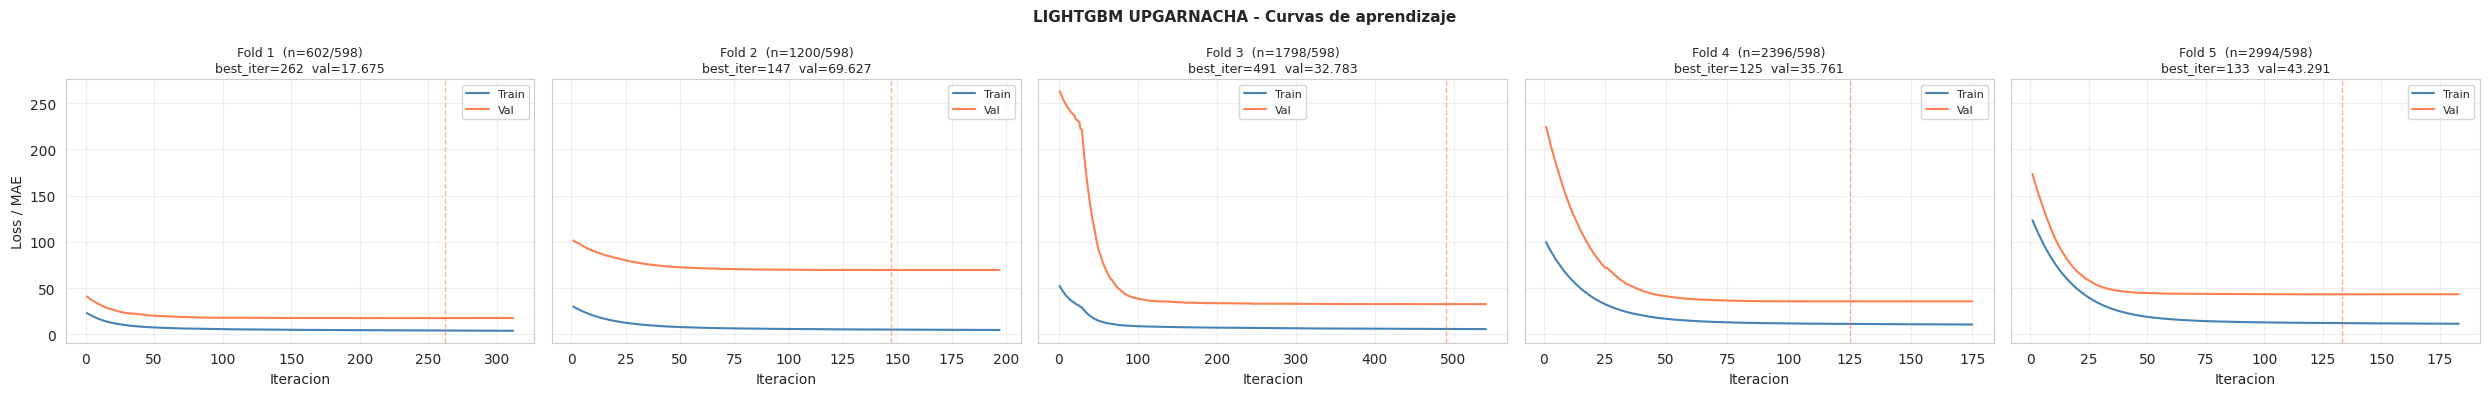

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/FVARENA_learning_curves.png


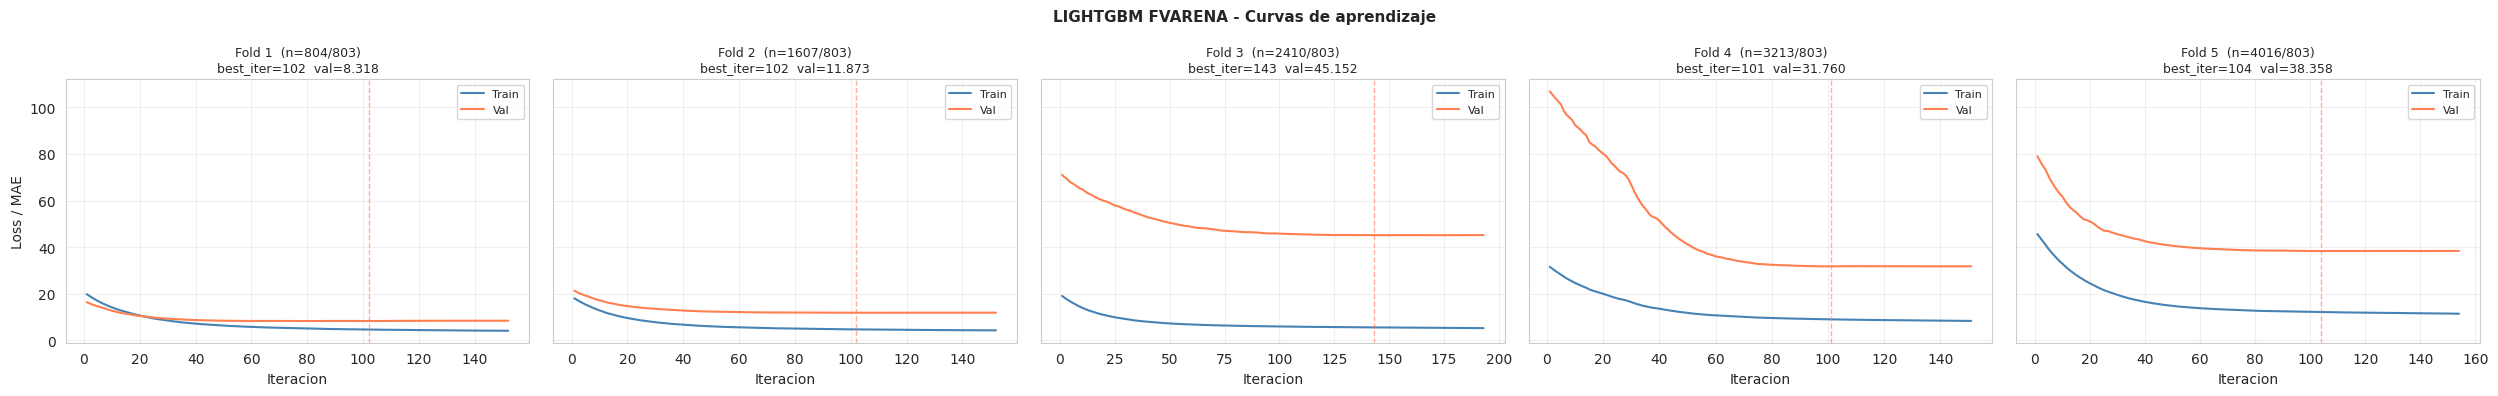

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/NBALBOA_learning_curves.png


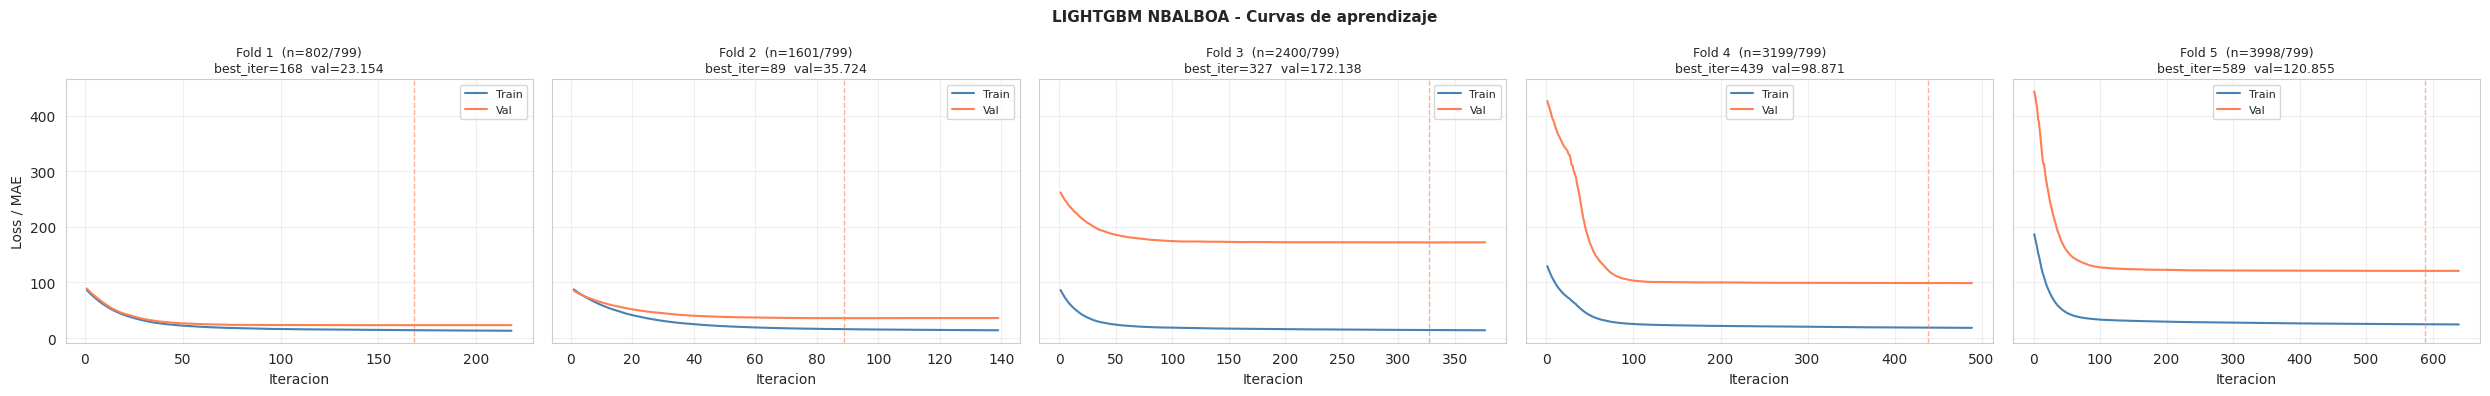

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/RODRI_learning_curves.png


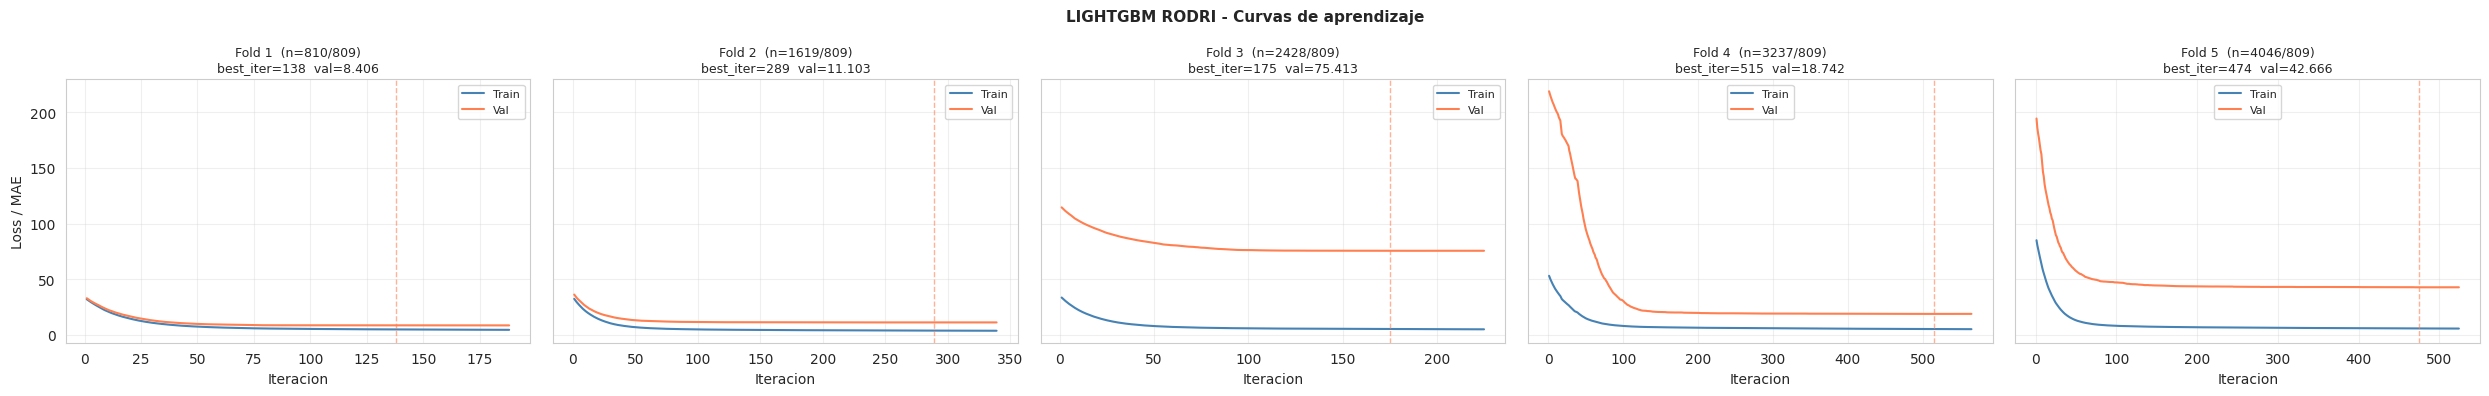

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/UFMULA_learning_curves.png


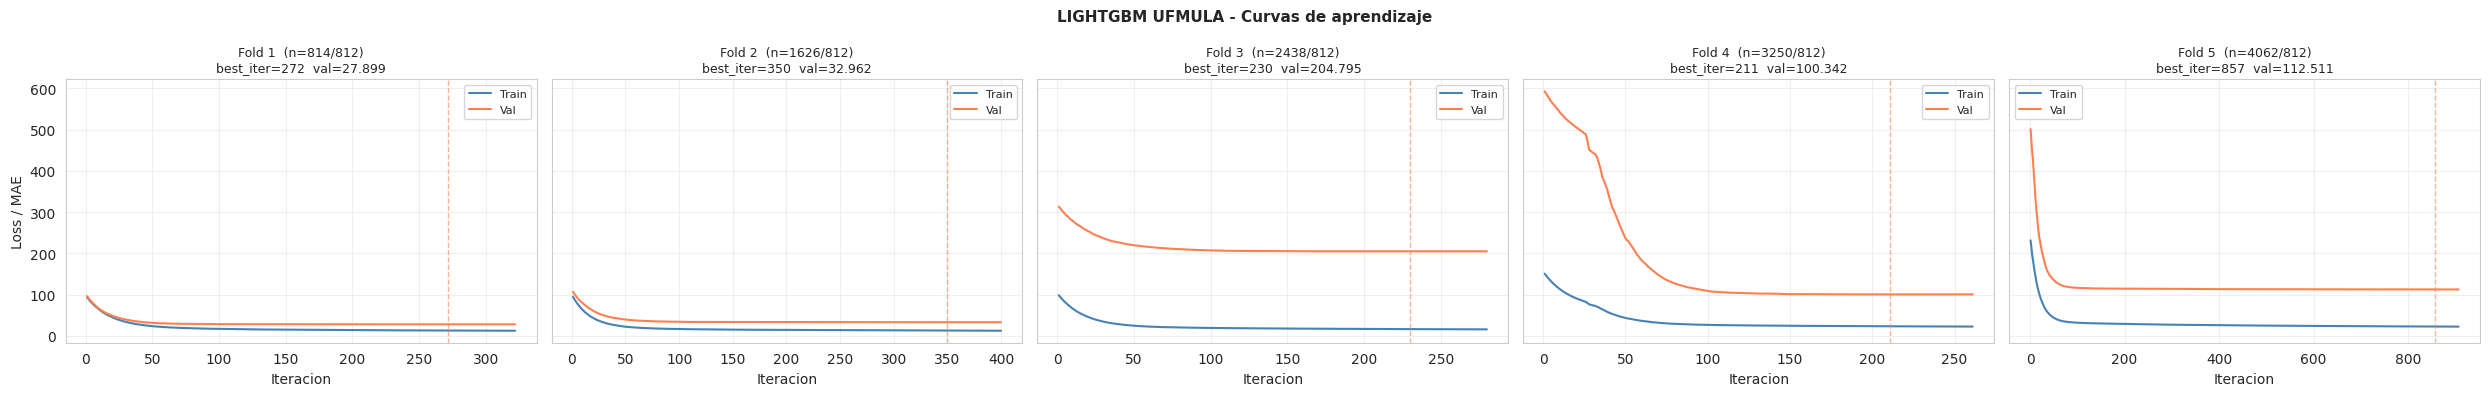

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/TALASOL_learning_curves.png


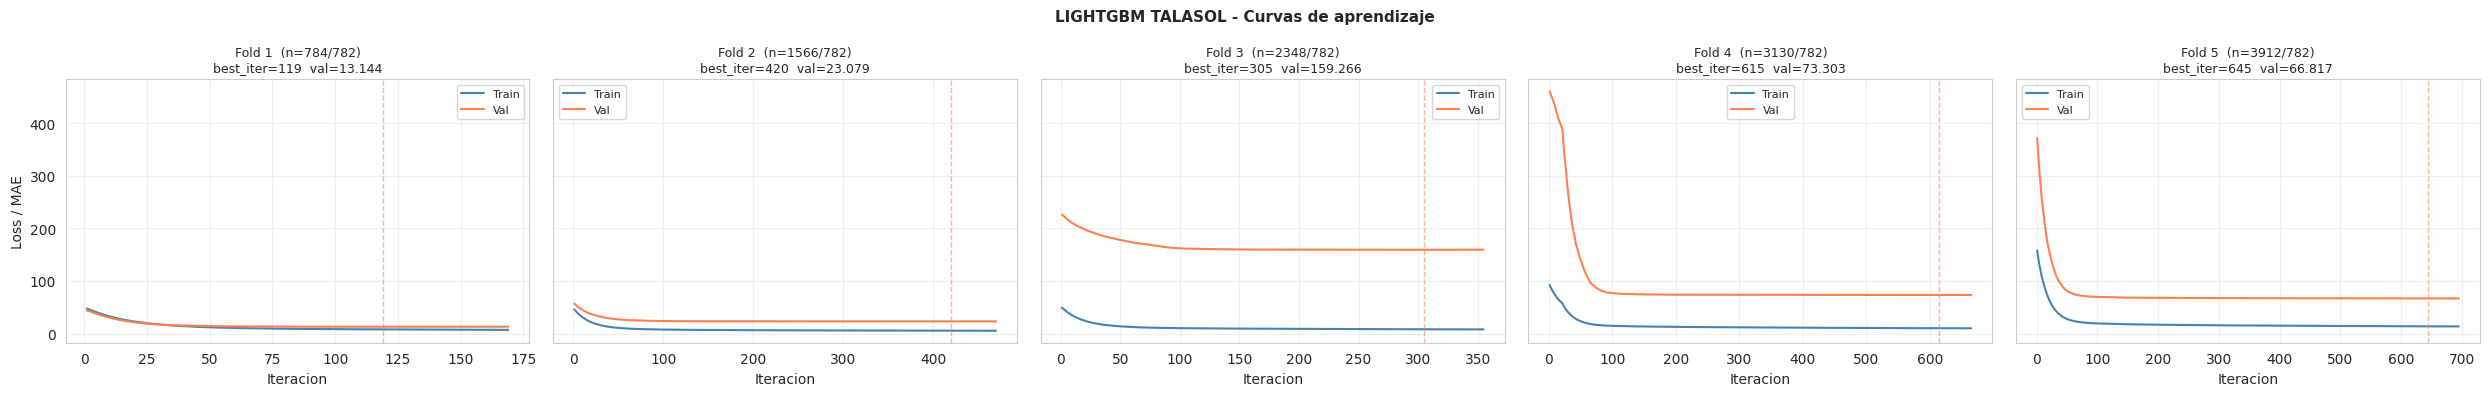

  Curvas guardadas


In [9]:
# ============================================================================
# 5a. CURVAS DE APRENDIZAJE (learning curves por fold)
# ============================================================================

print('[5a/6] Curvas de aprendizaje...')

for planta in plantas_run:
    model = all_models[planta]
    hists = model.fold_histories_ if USE_KFOLD else [{
        'fold': 1, 'n_train': '?', 'n_val': '?',
        'best_iter': model.best_iteration_,
        'best_val_mae': min(model.evals_result_['val'][_get_metric_key(model.evals_result_)]),
        'train_mae_curve': model.evals_result_['train'].get(_get_metric_key(model.evals_result_, 'train'), []),
        'val_mae_curve':   model.evals_result_['val'].get(_get_metric_key(model.evals_result_, 'val'), []),
    }]

    plot_learning_curves(hists, planta, 'lightgbm', save_dir=rm.figures_dir)

print('  Curvas guardadas')

[5b/6] Feature importance...


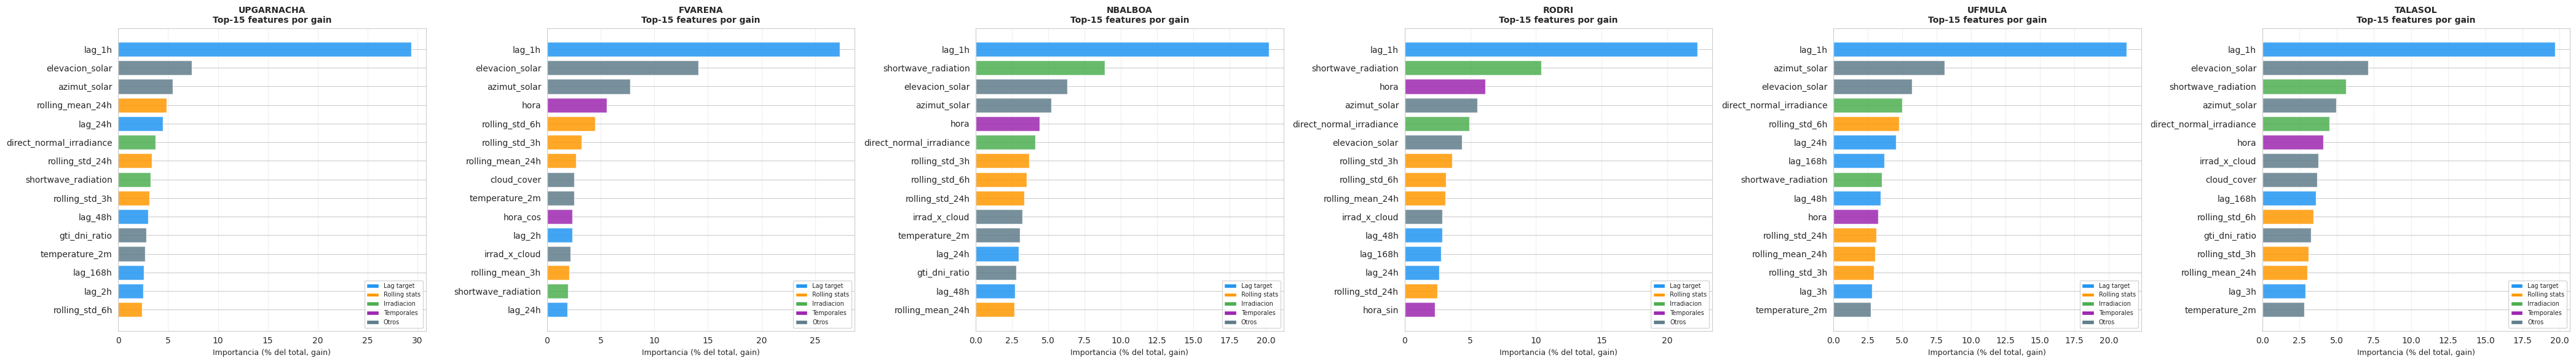

  Feature importance guardada


In [10]:
# ============================================================================
# 5b. FEATURE IMPORTANCE (visualización específica LightGBM)
# ============================================================================

print('[5b/6] Feature importance...')

fig, axes = plt.subplots(1, len(plantas_run),
                          figsize=(7 * len(plantas_run), 6),
                          sharey=False)
if len(plantas_run) == 1:
    axes = [axes]

for ax, planta in zip(axes, plantas_run):
    model  = all_models[planta]
    df_imp = model.get_feature_importance(importance_type='gain').head(15)

    colors = ['#2196F3' if 'lag_' in f
              else '#FF9800' if 'rolling_' in f
              else '#4CAF50' if any(x in f for x in ['radiation', 'irradiance', 'tilted'])
              else '#9C27B0' if any(x in f for x in ['hora', 'dia', 'mes'])
              else '#607D8B'
              for f in df_imp['feature']]

    bars = ax.barh(df_imp['feature'][::-1], df_imp['importance_pct'][::-1],
                   color=colors[::-1], alpha=0.85, edgecolor='white')
    ax.set_xlabel('Importancia (% del total, gain)', fontsize=9)
    ax.set_title(f'{planta}\nTop-15 features por gain', fontweight='bold', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2196F3', label='Lag target'),
        Patch(facecolor='#FF9800', label='Rolling stats'),
        Patch(facecolor='#4CAF50', label='Irradiacion'),
        Patch(facecolor='#9C27B0', label='Temporales'),
        Patch(facecolor='#607D8B', label='Otros'),
    ]
    ax.legend(handles=legend_elements, fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(rm.figures_dir / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Feature importance guardada')

[5c/6] Diagnóstico y series temporales...
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/UPGARNACHA_diagnostic.png


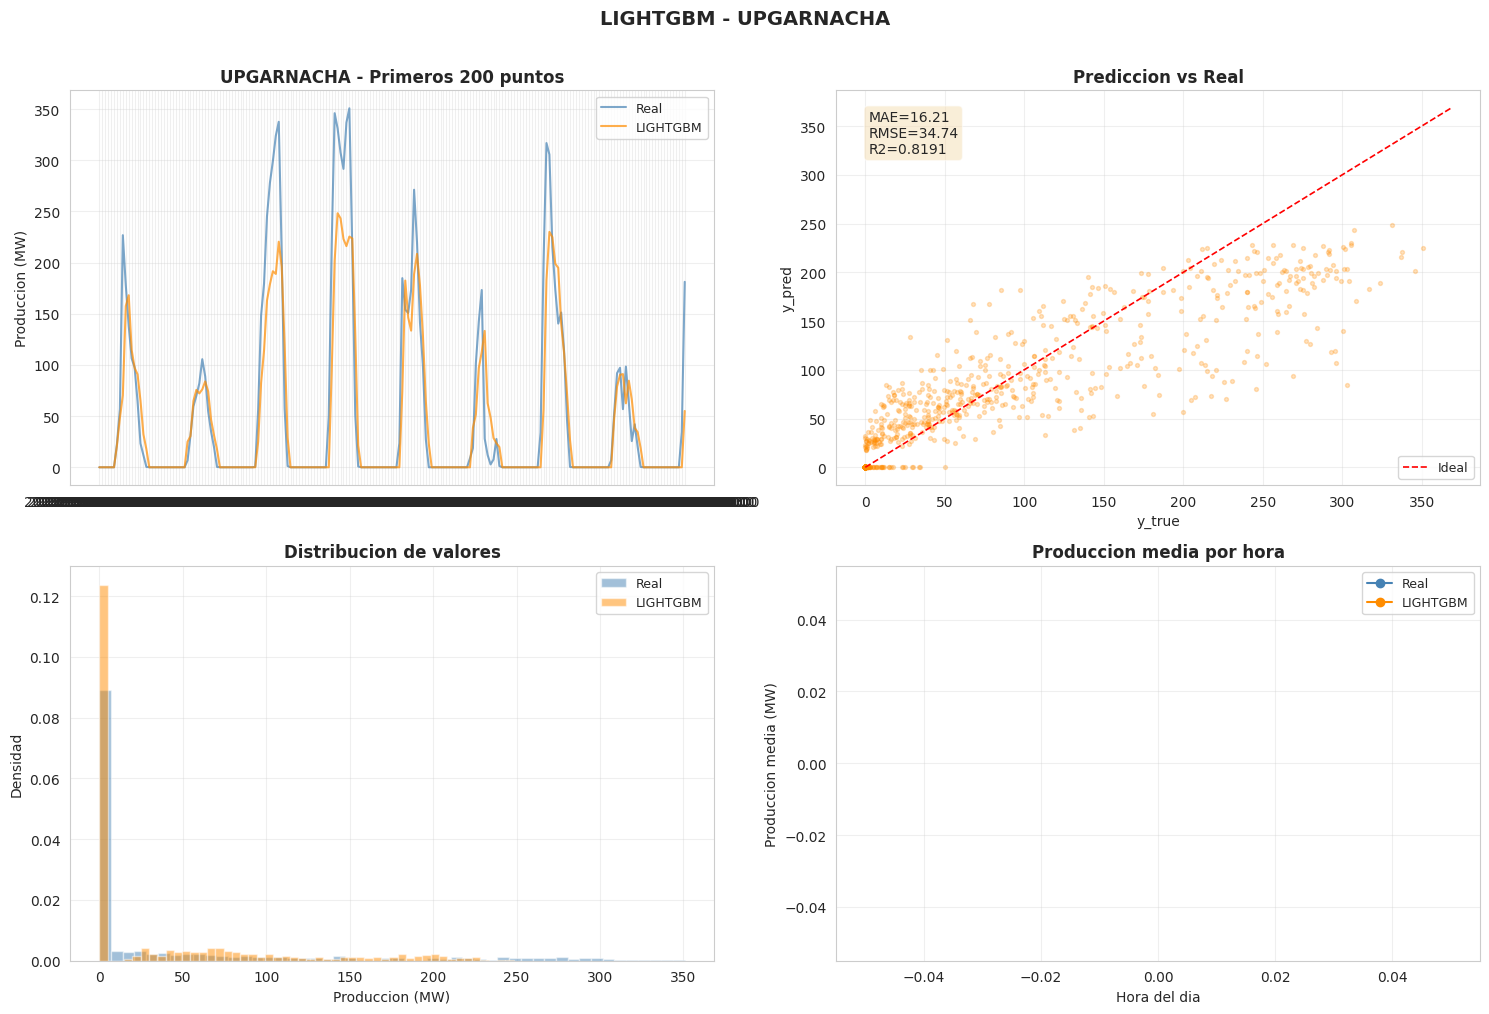

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/UPGARNACHA_timeseries.png


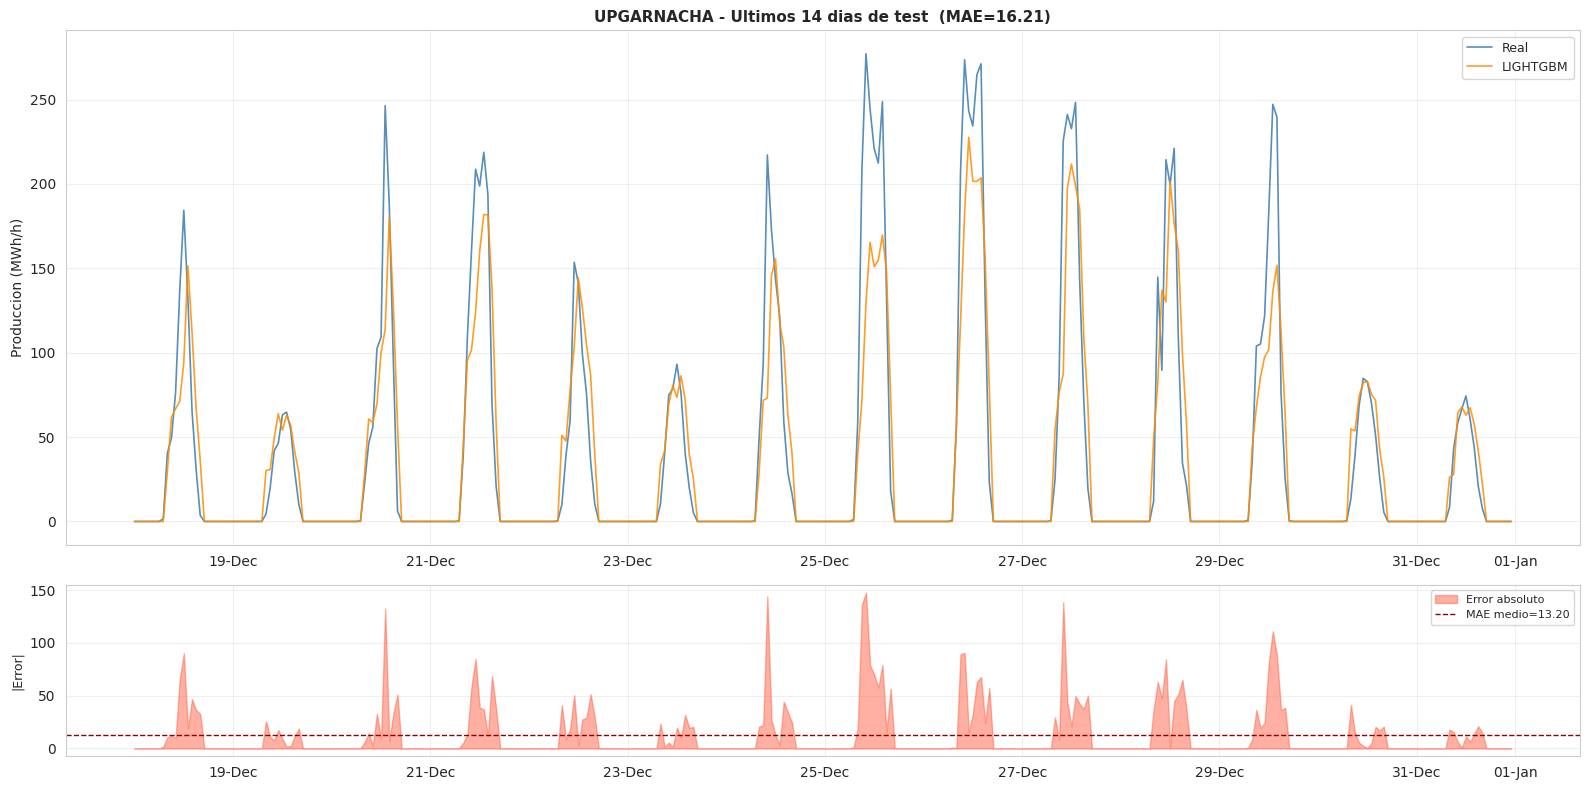

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/FVARENA_diagnostic.png


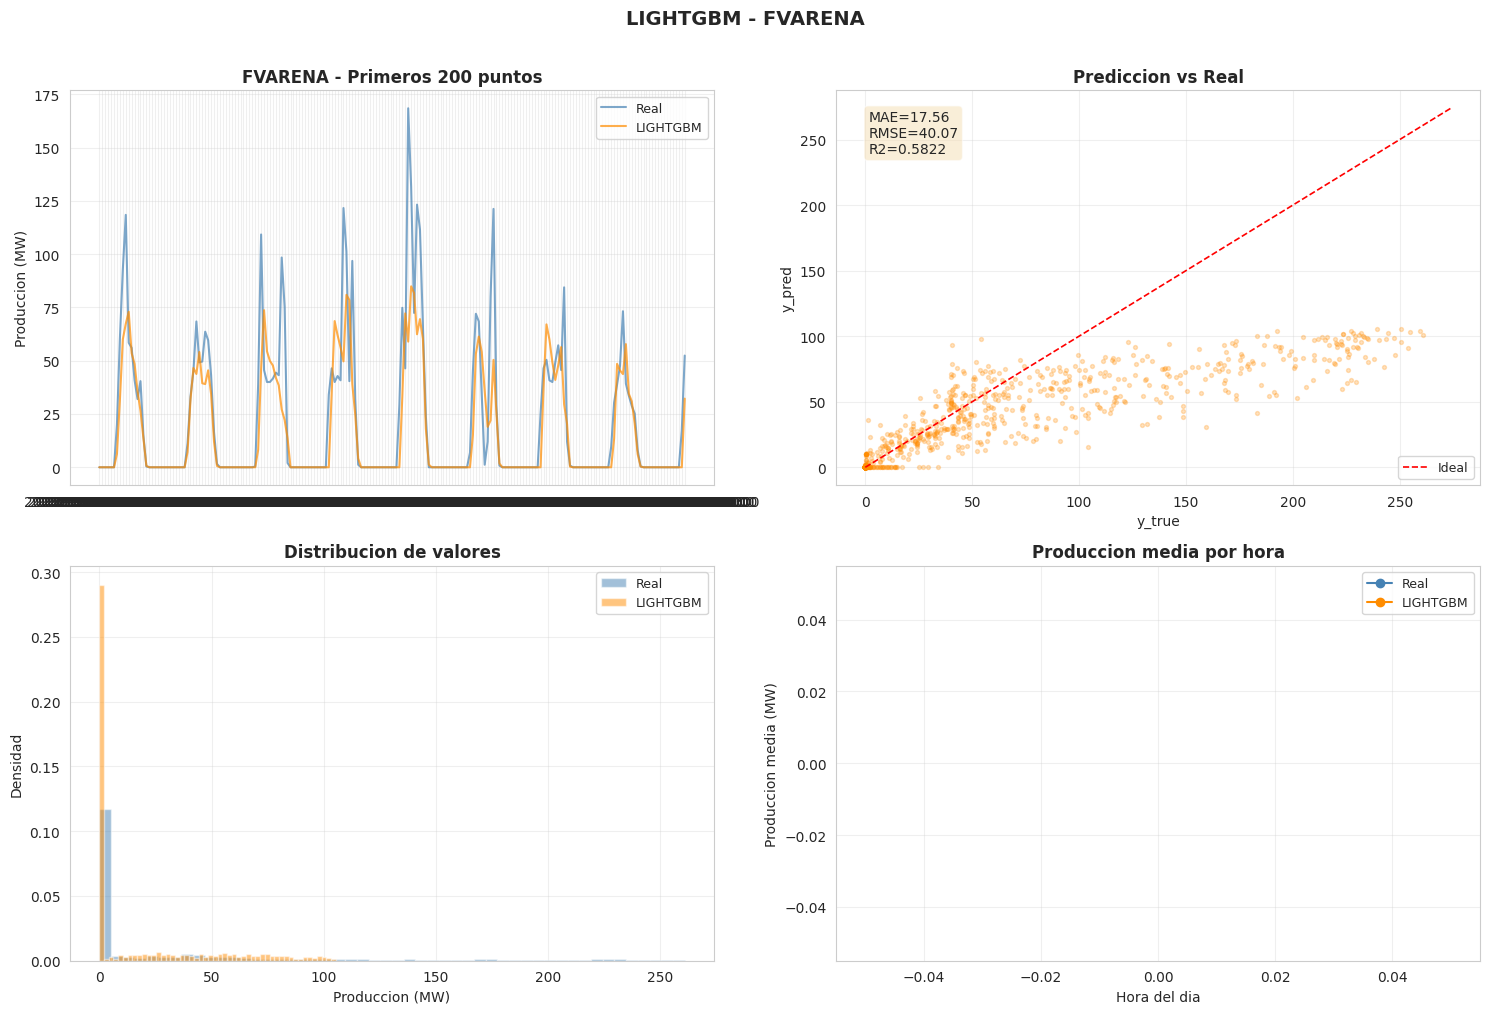

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/FVARENA_timeseries.png


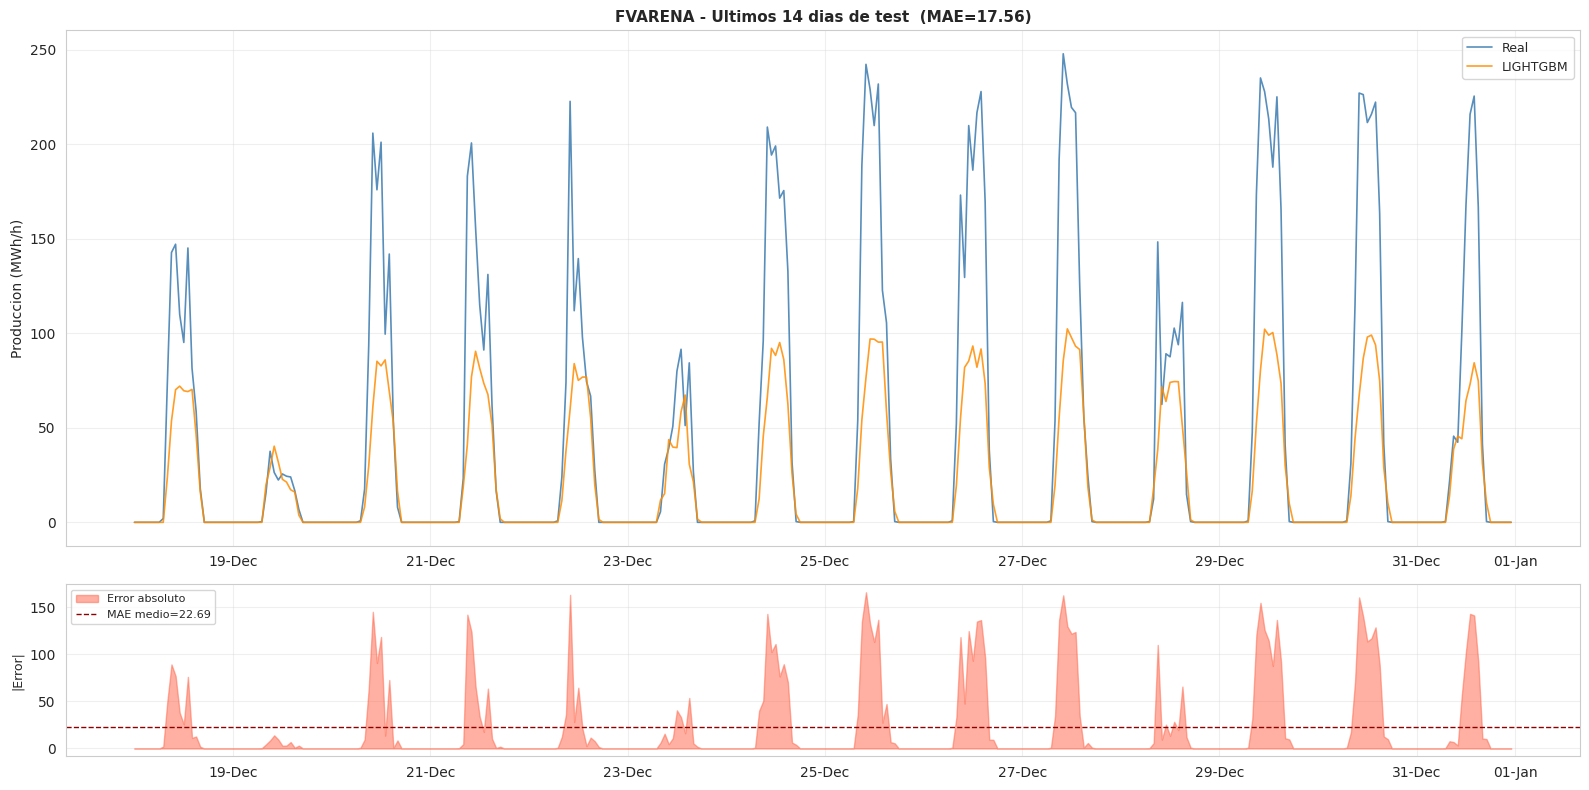

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/NBALBOA_diagnostic.png


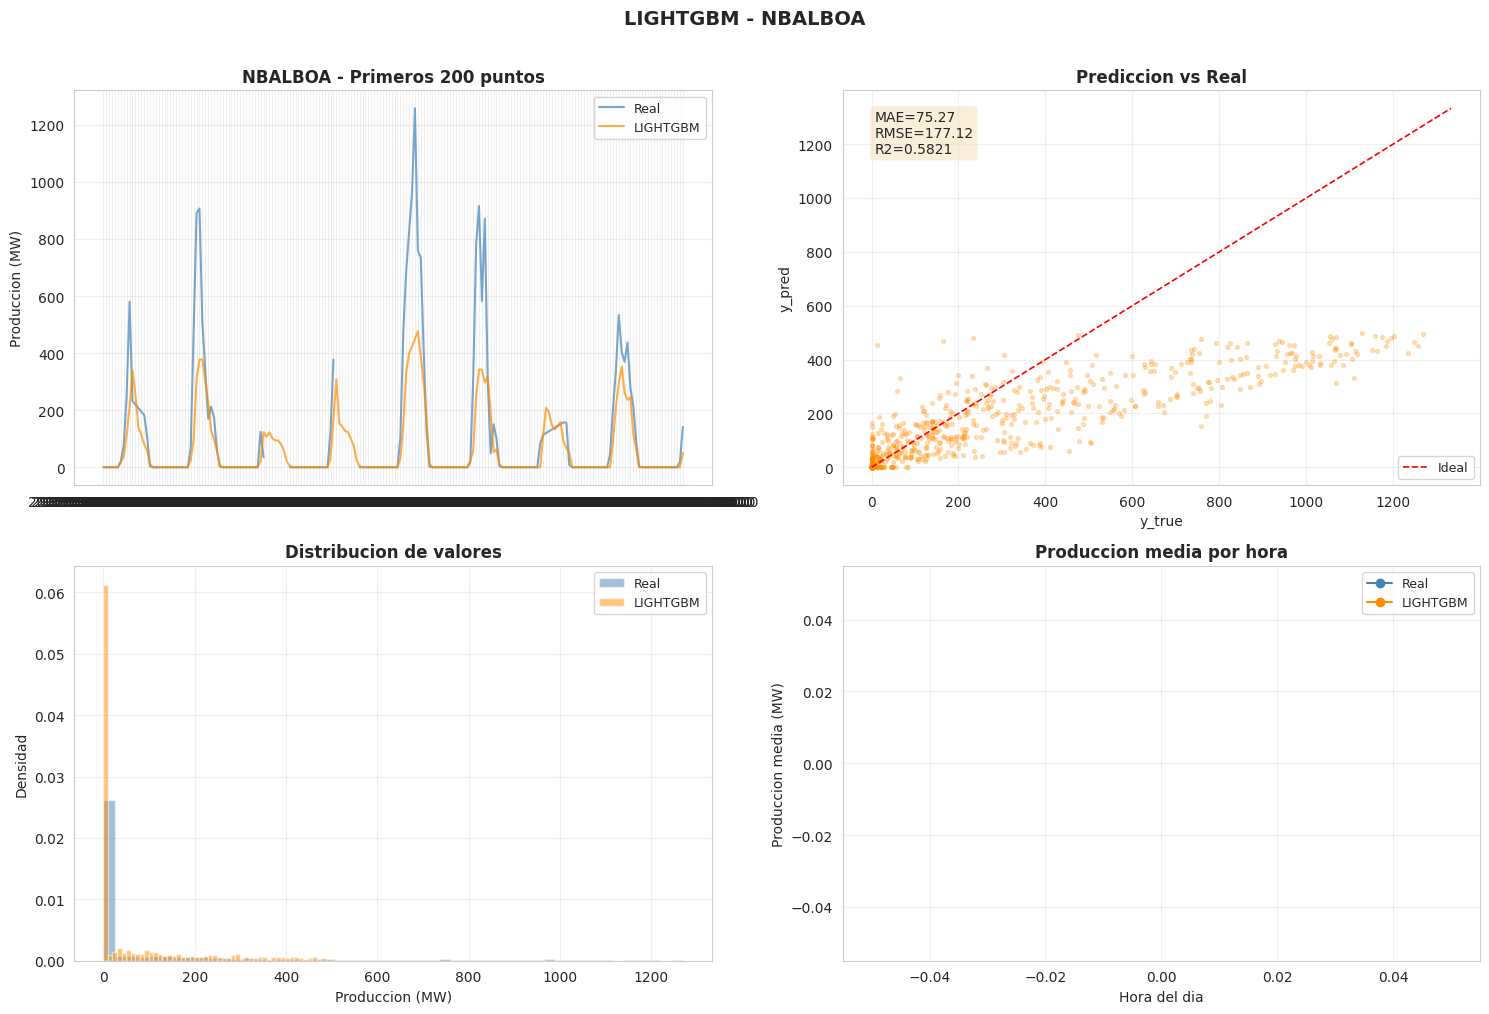

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/NBALBOA_timeseries.png


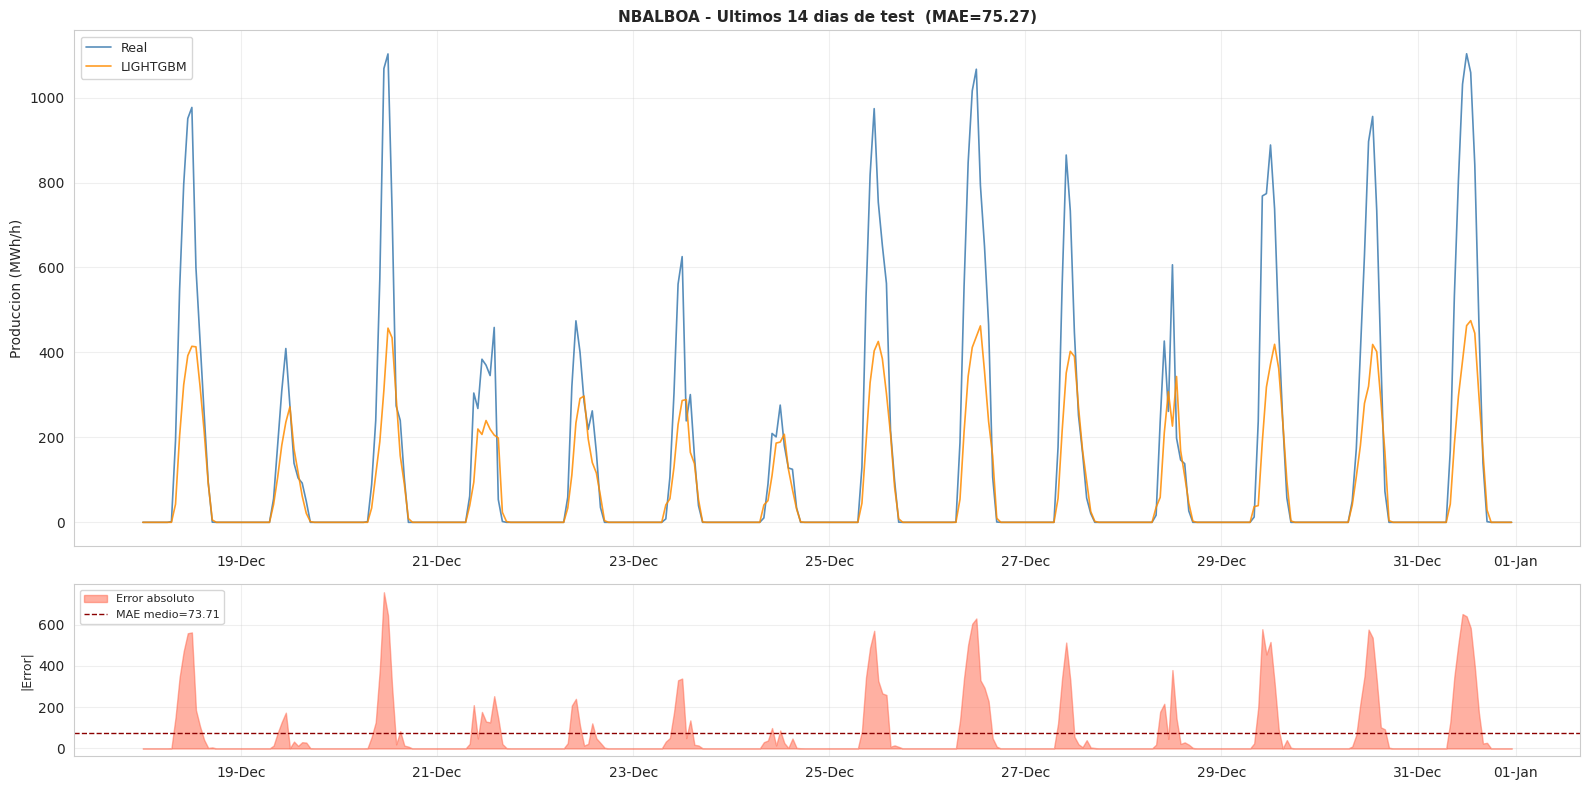

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/RODRI_diagnostic.png


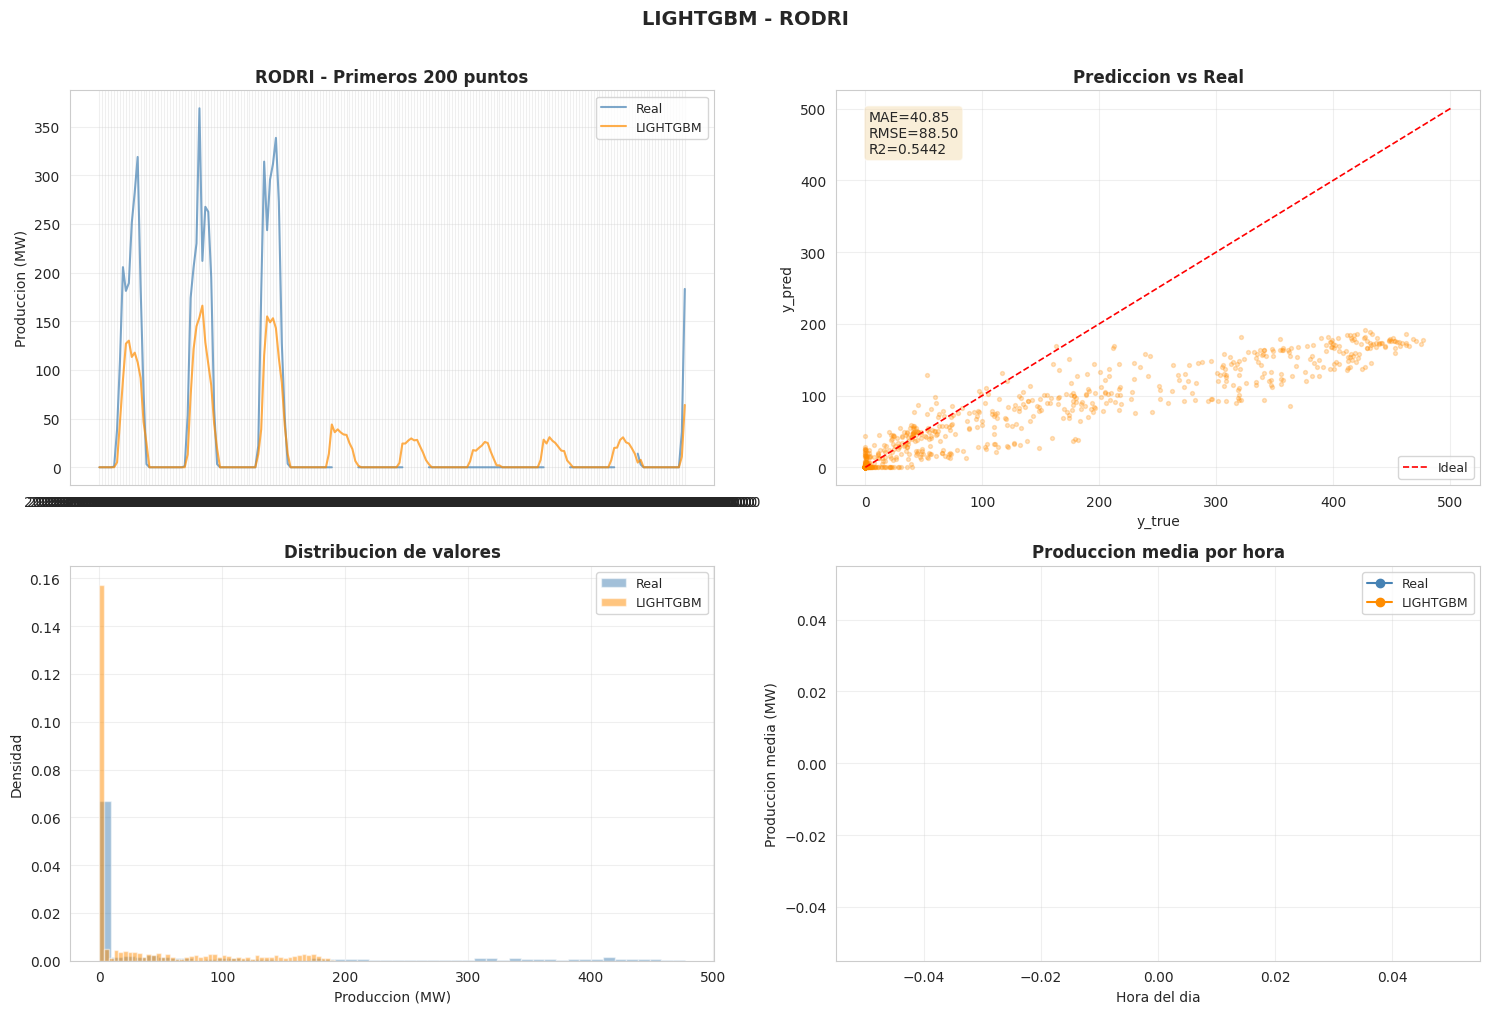

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/RODRI_timeseries.png


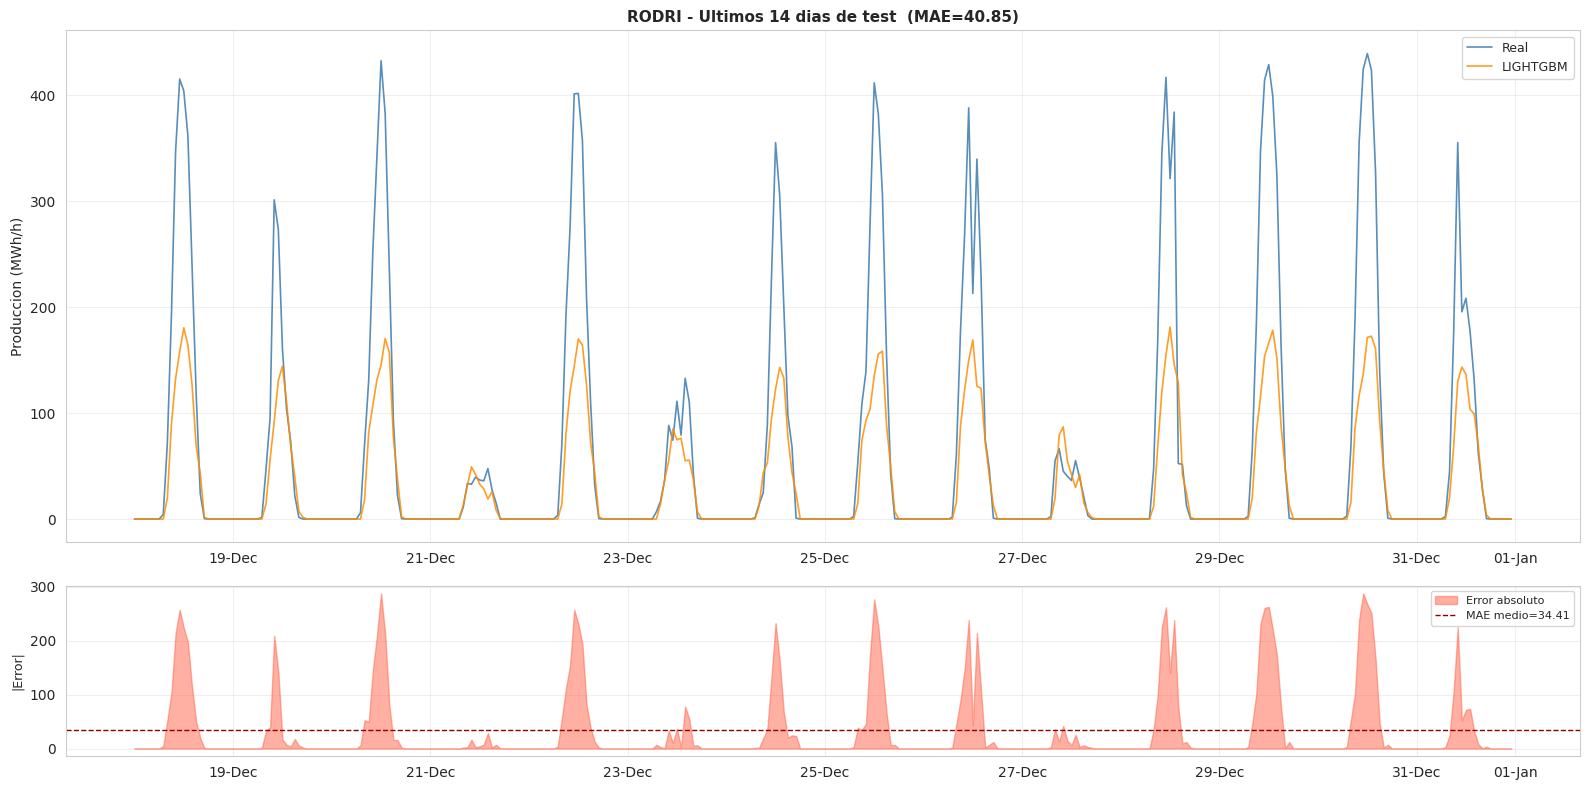

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/UFMULA_diagnostic.png


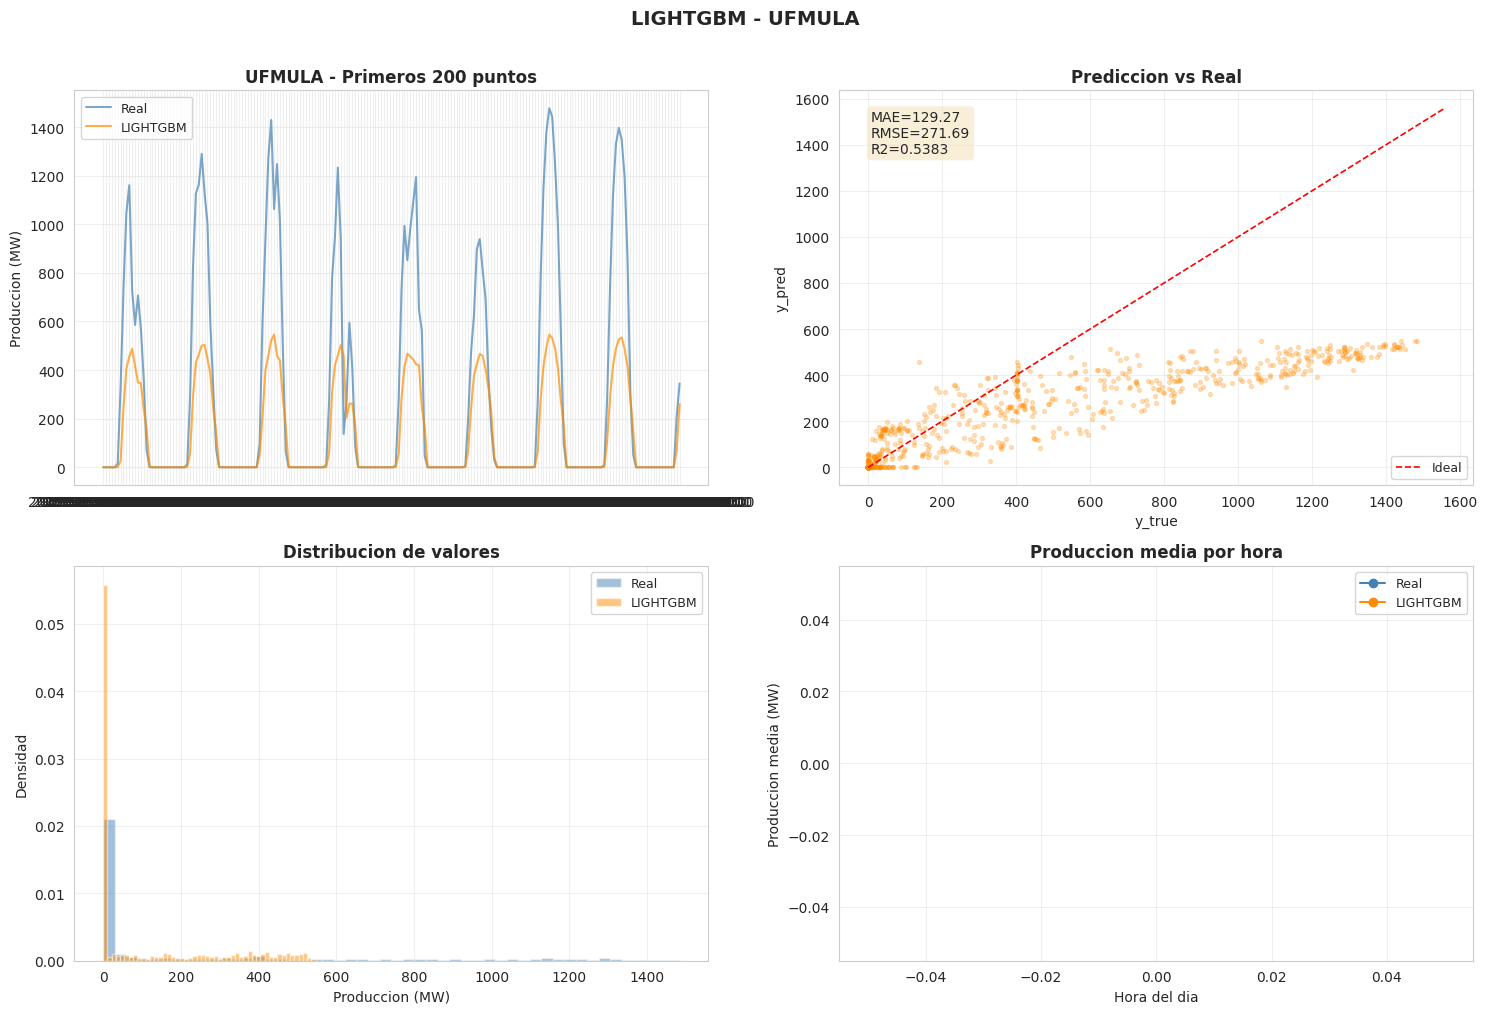

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/UFMULA_timeseries.png


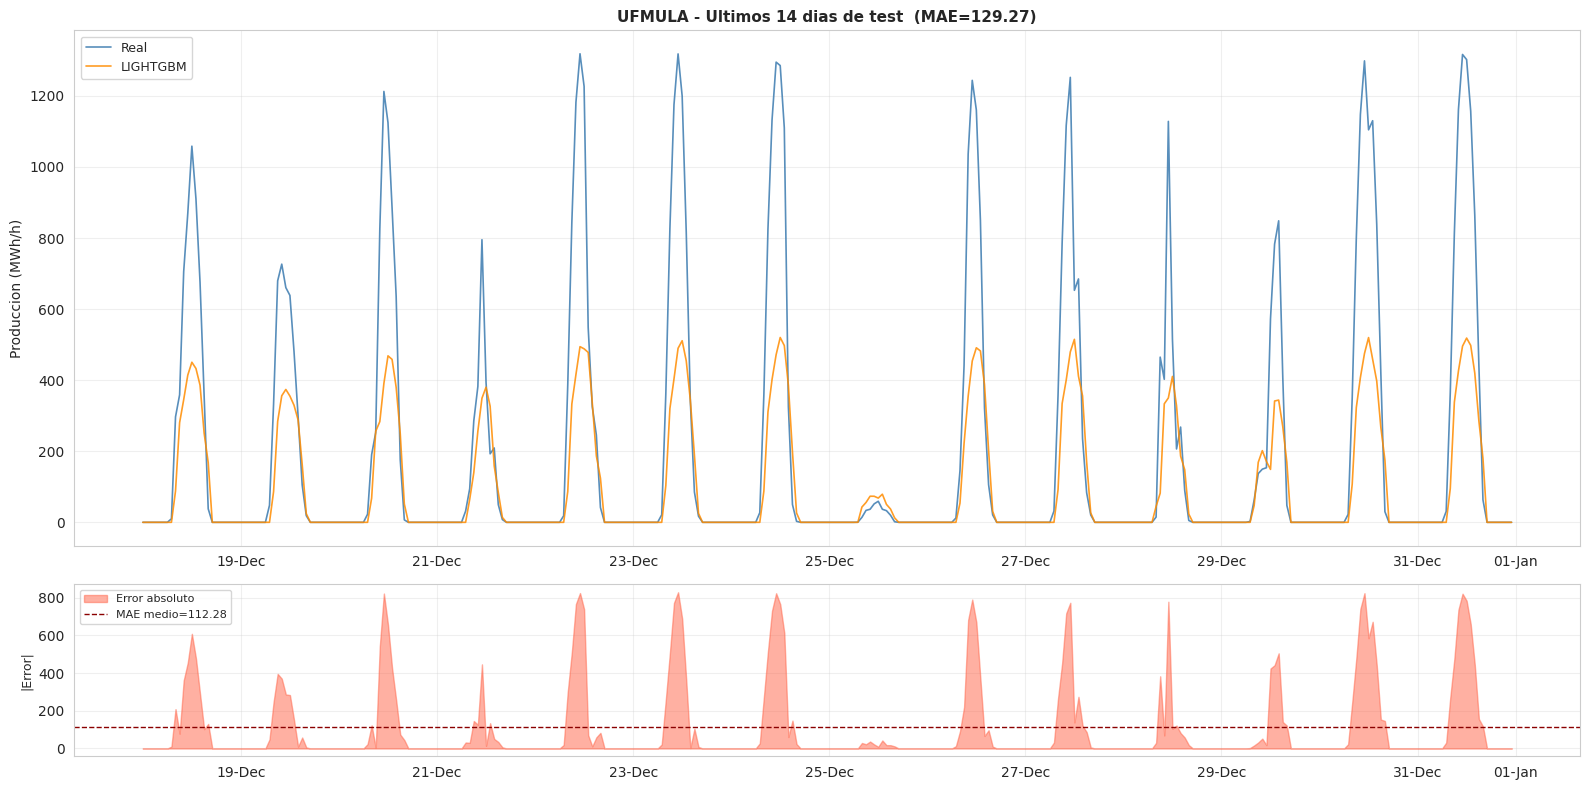

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/TALASOL_diagnostic.png


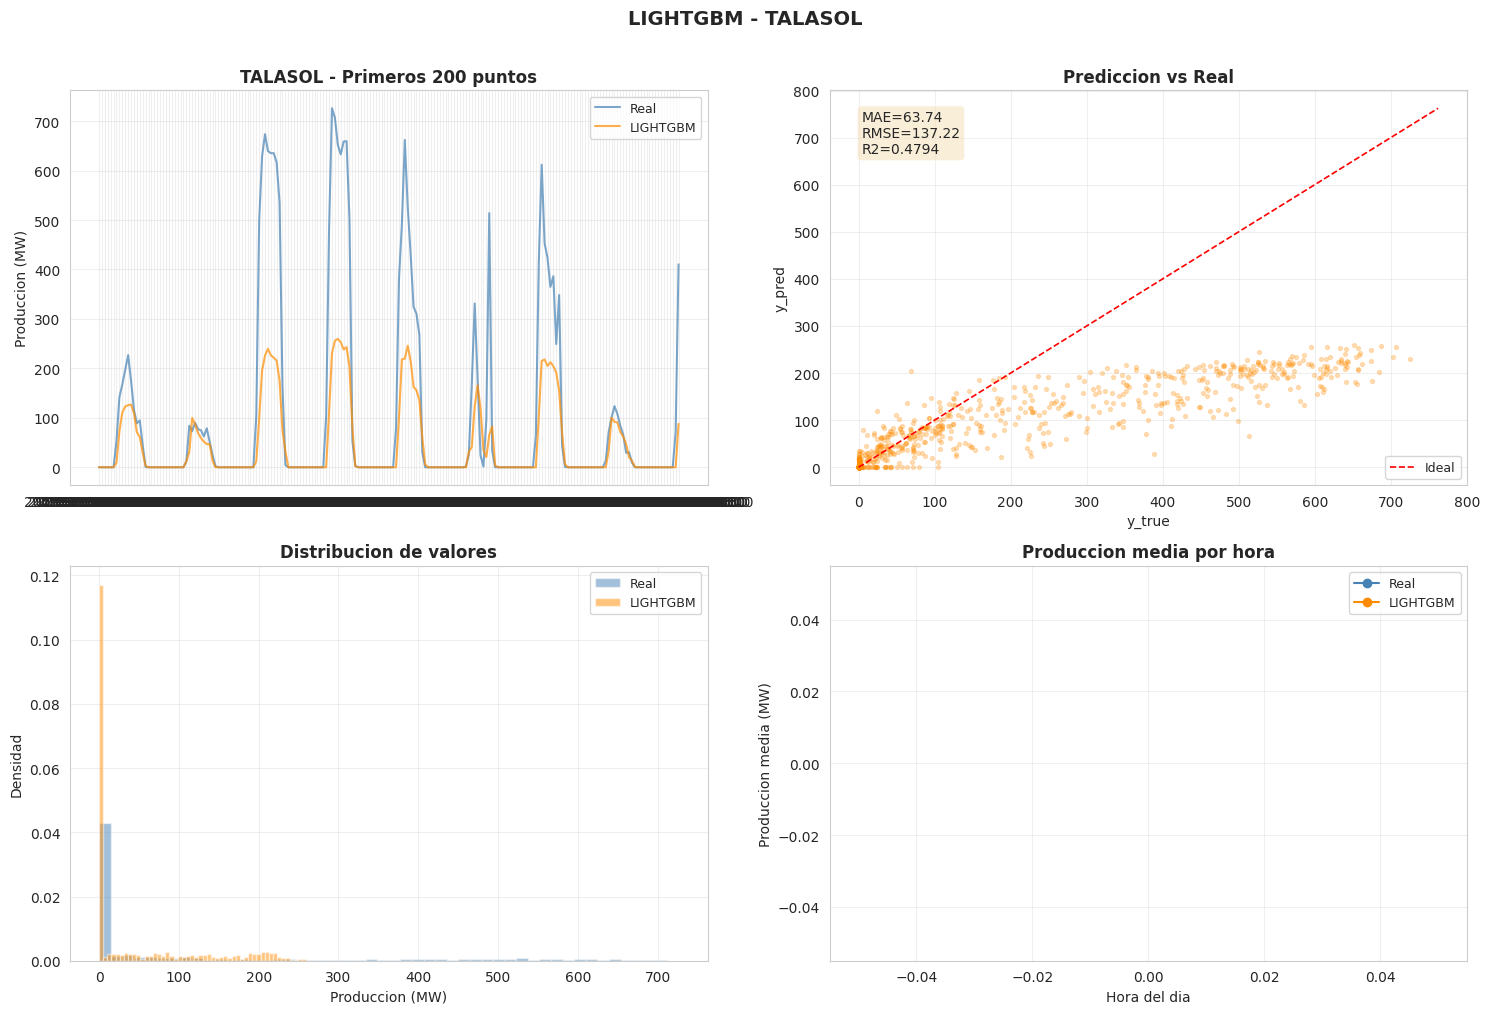

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/TALASOL_timeseries.png


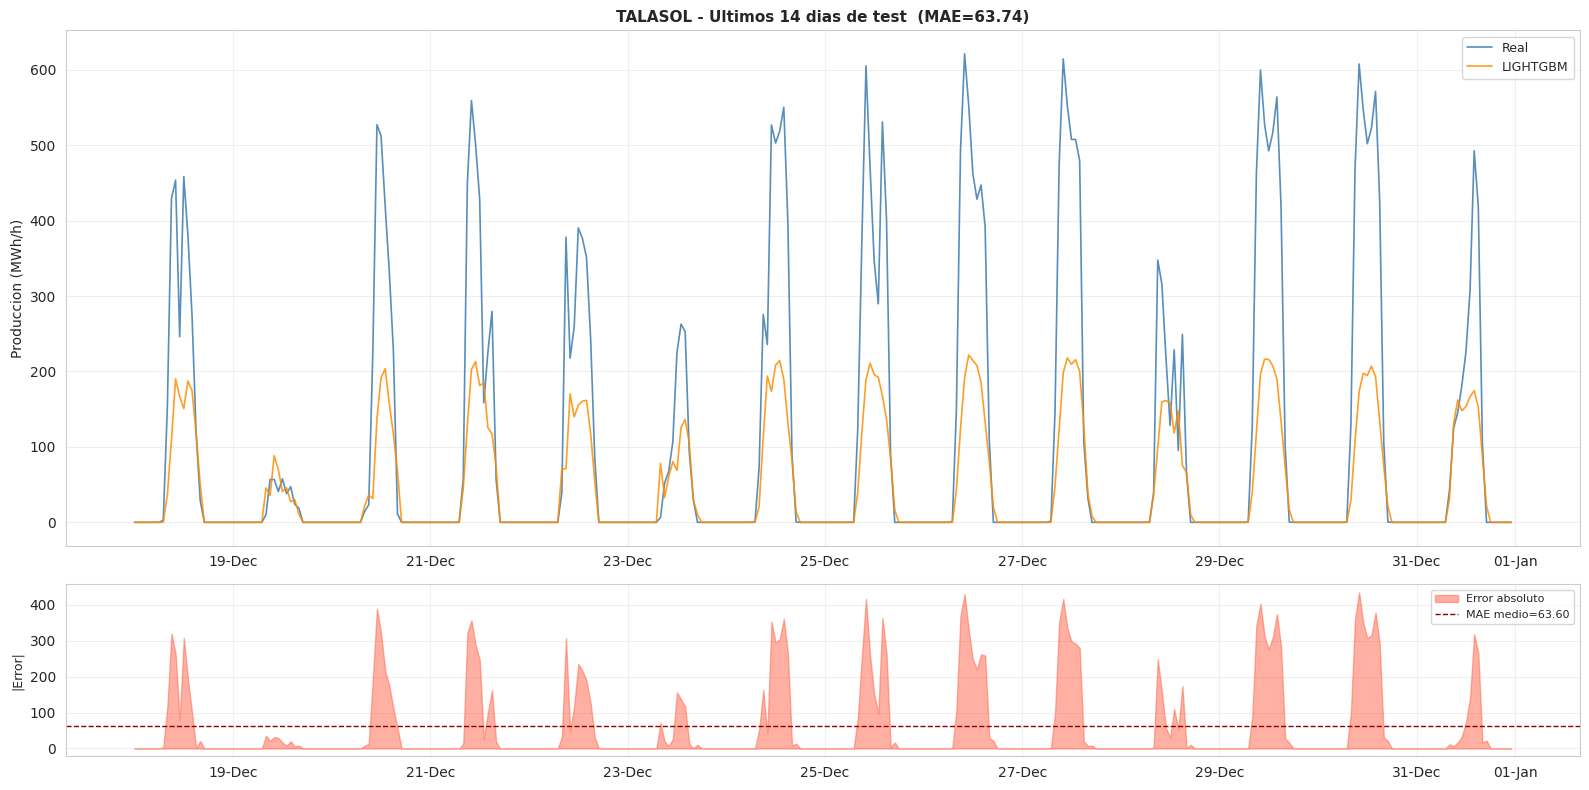

  Diagnóstico y series temporales guardadas


In [11]:
# ============================================================================
# 5c. DIAGNÓSTICO POR PLANTA (4 paneles) + SERIE TEMPORAL
# ============================================================================

print('[5c/6] Diagnóstico y series temporales...')

for planta in plantas_run:
    df_p = df_results[df_results['planta_nombre'] == planta].copy()

    # Plot diagnóstico 4-panel
    plot_diagnostic(df_p, planta, 'lightgbm', save_dir=rm.figures_dir)

    # Serie temporal extendida (14 días)
    plot_timeseries(df_p, planta, 'lightgbm', save_dir=rm.figures_dir, days=14)

print('  Diagnóstico y series temporales guardadas')

In [12]:
# (Scatter y distribución de errores integrados en plot_diagnostic arriba)

[5e/6] Comparación entre modelos disponibles...
  Solo hay metricas de lightgbm — mostrando resultado individual.
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/comparison_all_models.png


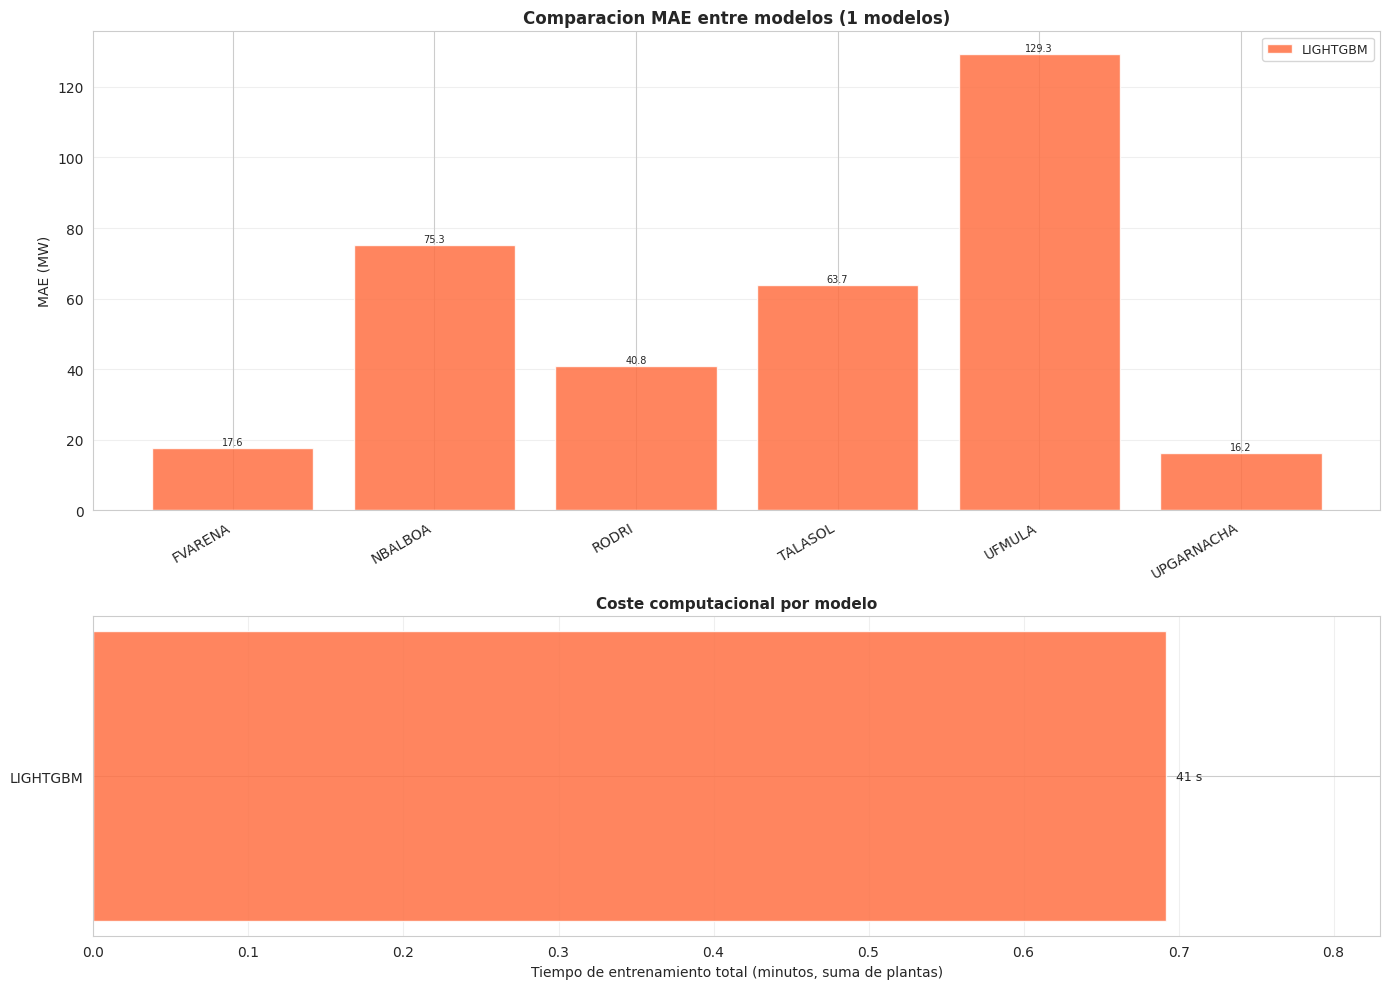

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/metrics/comparison_all_models.csv


In [13]:
# ============================================================================
# 5e. COMPARACIÓN ENTRE MODELOS
# ============================================================================

print('[5e/6] Comparación entre modelos disponibles...')

plot_model_comparison(df_metrics_lgbm, 'lightgbm', save_dir=rm.figures_dir)

In [14]:
# ============================================================================
# 6. RESUMEN FINAL
# ============================================================================

print('\n' + '=' * 80)
print('RESUMEN FINAL - LightGBM')
print('=' * 80)

print(f'\nMétricas LightGBM (test, solo horas diurnas):')
print(f"  MAE  medio: {df_metrics_lgbm['MAE'].mean():.2f} +/- {df_metrics_lgbm['MAE'].std():.2f}")
print(f"  RMSE medio: {df_metrics_lgbm['RMSE'].mean():.2f} +/- {df_metrics_lgbm['RMSE'].std():.2f}")
print(f"  R2   medio: {df_metrics_lgbm['R2'].mean():.4f}")

print(f'\nArchivos generados en {rm.results_dir}:')
print(f'  Metricas:    {rm.metrics_dir}/')
print(f'  Figuras:     {rm.figures_dir}/')
print(f'  Checkpoints: {rm.ckpt_dir}/')

print('\nExperimento LightGBM completado')
print('=' * 80)


RESUMEN FINAL - LightGBM

Métricas LightGBM (test, solo horas diurnas):
  MAE  medio: 57.15 +/- 42.62
  RMSE medio: 124.89 +/- 90.64
  R2   medio: 0.5909

Archivos generados en /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare:
  Metricas:    /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/
  Figuras:     /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lightgbm/
  Checkpoints: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/lightgbm/

Experimento LightGBM completado
